<h1>Quick Start

In [1]:
import pandas as pd
import pickle

# --- 1) 댓글 단위 전처리 결과 ---
comments_df = pd.read_csv('preprocessed_comments.csv', encoding='utf-8-sig')

# --- 2) 영상 단위 집계 결과 ---
video_df = pd.read_csv('video_documents.csv', encoding='utf-8-sig')

# --- 3) TF-IDF 행렬 ---
with open('tfidf_matrix.pkl', 'rb') as f:
    tfidf_matrix = pickle.load(f)

# --- 4) TF-IDF Vectorizer ---
with open('tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

# === 로드 확인 ===
print('=== comments_df ===')
print(f'  Shape: {comments_df.shape}')
print(f'  Columns: {list(comments_df.columns)}')
print(comments_df.head(2))

print('\n=== video_df ===')
print(f'  Shape: {video_df.shape}')
print(f'  Columns: {list(video_df.columns)}')
print(video_df.head(2))

print(f'\n=== tfidf_matrix ===')
print(f'  Type: {type(tfidf_matrix)}')
print(f'  Shape: {tfidf_matrix.shape}')

print(f'\n=== vectorizer ===')
print(f'  Type: {type(vectorizer)}')
print(f'  Feature 수: {len(vectorizer.get_feature_names_out())}')
print(f'  Feature 샘플: {list(vectorizer.get_feature_names_out()[:10])}')

=== comments_df ===
  Shape: (9466, 8)
  Columns: ['Video Title', 'Video URL', 'Likes', 'Comment', 'category', 'Comment_clean', 'lang', 'tokens_clean']
                                         Video Title  \
0  NewJeans (뉴진스) 'OMG' Official MV (Performance ...   
1  NewJeans (뉴진스) 'OMG' Official MV (Performance ...   

                                           Video URL    Likes  \
0  https://www.youtube.com/watch?v=sVTy_wmn5SU&li...  2490682   
1  https://www.youtube.com/watch?v=sVTy_wmn5SU&li...  2490682   

                                             Comment category  \
0  민희진님은 절대 ㅈㅅ 안한다고 했습니다.\n️️️️️️️️️️\n이 댓글이 삭제된다...      뉴진스   
1  뉴진스 데뷔 미룬 것도 르세라핌이 5.2에 데뷔해야해서 그런거냐ㅜ방시혁 정신 좀 차...      뉴진스   

                                       Comment_clean lang  \
0  민희진님은 절대 안한다고 했습니다 이 댓글이 삭제된다면 하이브에서 삭제하는 것입니다...   ko   
1  뉴진스 데뷔 미룬 것도 르세라핌이 5 2에 데뷔해야해서 그런거냐 방시혁 정신 좀 차...   ko   

                         tokens_clean  
0  민희진 절대 댓글 삭제 하이브 삭제 좋다 누르다 위로 올려주다  
1   뉴진스 데뷔 미루다 세라핌 데뷔 그

<h1>K-Means 모델 학습

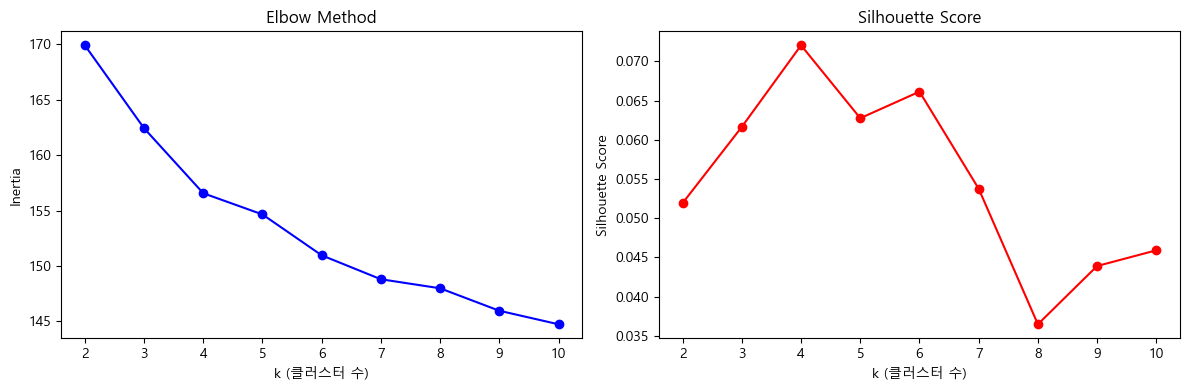

최적 k: 4
Silhouette Score: 0.0721
클러스터별 영상 수: [59 48 49 41]


In [3]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 윈도우 환경 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 그래프에서 마이너스(-) 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
with open('tfidf_matrix.pkl', 'rb') as f:
    tfidf_matrix = pickle.load(f)
video_df = pd.read_csv('video_documents.csv', encoding='utf-8-sig')

# --- Elbow Method + Silhouette Score ---
K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_matrix)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(tfidf_matrix, km.labels_))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k (클러스터 수)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, sil_scores, 'ro-')
axes[1].set_xlabel('k (클러스터 수)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.savefig('kmeans_optimal_k.png', dpi=150)
plt.show()

# 최적 k로 최종 모델 학습 (예: k=4)
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(tfidf_matrix)

print(f'최적 k: {best_k}')
print(f'Silhouette Score: {silhouette_score(tfidf_matrix, kmeans.labels_):.4f}')
print(f'클러스터별 영상 수: {np.bincount(kmeans.labels_)}')

<h1>PCA 2D 시각화로 클러스터 확인

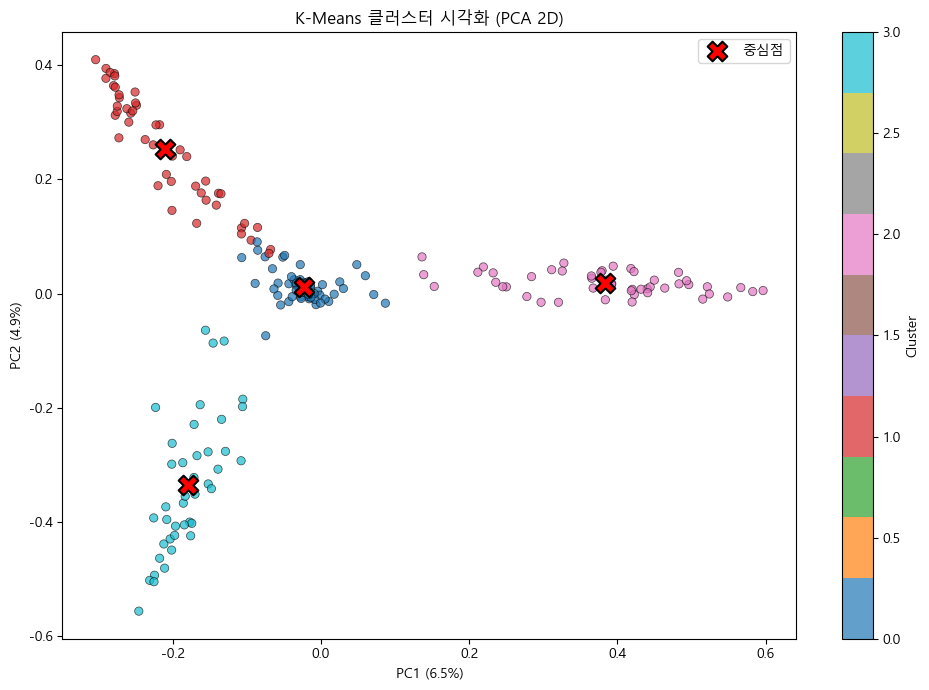

클러스터 0: 월드컵, 보다, 선수, 경기, 축구, 손흥민, 영상, 좋다, 이강인, 감독
클러스터 1: ai, 인간, 교수, 보다, 시대, 사람, 가다, 감사하다, 판사, 생각
클러스터 2: 뉴진스, newjeans, 노래, miss, new, song, never, jean, danielle, like
클러스터 3: 전쟁, 이스라엘, 이란, 미국, 네타냐후, 트럼프, 국민, 나라, 악마, 국가


In [4]:
from sklearn.decomposition import PCA

# PCA로 2차원 축소
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())

# 시각화
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    coords[:, 0], coords[:, 1],
    c=kmeans.labels_, cmap='tab10', alpha=0.7, edgecolors='k', linewidths=0.5
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('K-Means 클러스터 시각화 (PCA 2D)')

# 클러스터 중심점 표시
centers_2d = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centers_2d[:, 0], centers_2d[:, 1],
    c='red', marker='X', s=200, edgecolors='k', linewidths=1.5, label='중심점'
)
plt.legend()
plt.tight_layout()
plt.savefig('kmeans_pca_visualization.png', dpi=150)
plt.show()

# 각 클러스터별 상위 키워드 확인
with open('tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

feature_names = vectorizer.get_feature_names_out()
for i in range(best_k):
    center = kmeans.cluster_centers_[i]
    top_indices = center.argsort()[::-1][:10]
    top_words = [feature_names[idx] for idx in top_indices]
    print(f'클러스터 {i}: {", ".join(top_words)}')

<h1>키워드 기반 클러스터 추천

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_by_cluster(keywords, top_n=5):
    """K-Means 클러스터 기반 키워드 추천

    Args:
        keywords: 검색 키워드 문자열 (공백 구분)
        top_n: 추천 영상 수
    """
    # 키워드 → TF-IDF 벡터 변환
    query_vec = vectorizer.transform([keywords])

    # 클러스터 예측
    cluster_id = kmeans.predict(query_vec)[0]

    # 해당 클러스터에 속한 영상 인덱스 추출
    cluster_indices = np.where(kmeans.labels_ == cluster_id)[0]

    # 클러스터 내 코사인 유사도 계산
    cluster_matrix = tfidf_matrix[cluster_indices]
    similarities = cosine_similarity(query_vec, cluster_matrix).flatten()

    # 유사도 기준 정렬
    sorted_order = similarities.argsort()[::-1][:top_n]

    print(f'검색 키워드: "{keywords}"')
    print(f'할당된 클러스터: {cluster_id} (클러스터 내 영상 수: {len(cluster_indices)}개)\n')

    for rank, order_idx in enumerate(sorted_order, 1):
        video_idx = cluster_indices[order_idx]
        row = video_df.iloc[video_idx]
        print(f'{rank}. [{row["category"]}] {row["Video Title"]}')
        print(f'   유사도: {similarities[order_idx]:.4f} | 좋아요: {row["Likes"]:,} | 댓글: {row["comment_count"]}건')
        print(f'   URL: {row["Video URL"]}')
        print()

# 사용 예시
recommend_by_cluster('감동 응원 열정', top_n=5)
recommend_by_cluster('전쟁 평화 국제', top_n=3)

검색 키워드: "감동 응원 열정"
할당된 클러스터: 0 (클러스터 내 영상 수: 59개)

1. [월드컵] 26 FIFA 월드컵 가즈아! 🔥 축덕 김민경의 짜릿한 트로피 투어 현장 [썰스티] Special Ep.
   유사도: 0.0963 | 좋아요: 78 | 댓글: 50건
   URL: https://www.youtube.com/watch?v=InhfSAfEHjM&pp=ygUJ7JuU65Oc7Lu1

2. [월드컵] 20년이 지났지만 잊을 수 없는 그 여름날! 2002 월드컵 뜨거웠던 7경기의 기억! ㅣ월드컵 메모리즈 / 14F
   유사도: 0.0873 | 좋아요: 54,773 | 댓글: 50건
   URL: https://www.youtube.com/watch?v=I9vK5EVTt0U&pp=ygUJ7JuU65Oc7Lu1

3. [월드컵] [MBC 한일월드컵] 2002년 6월의 함성, 대~한민국
   유사도: 0.0826 | 좋아요: 28,448 | 댓글: 50건
   URL: https://www.youtube.com/watch?v=gJuDdamvZ6M&pp=ygUJ7JuU65Oc7Lu1

4. [월드컵] 멀티골 넣고 미친 활약 보여줬던 조규성... 미 매체, “미친 경기”
   유사도: 0.0730 | 좋아요: 5,146 | 댓글: 47건
   URL: https://www.youtube.com/watch?v=U2YKyMJhT5c&pp=ygUJ7JuU65Oc7Lu1

5. [월드컵] 드라마도 이렇게는 못 쓴다...😂 경우의 수보다 중요한 건 '꺾이지 않는 마음' [카타르월드컵 H조 대한민국 vs 포르투갈]
   유사도: 0.0660 | 좋아요: 28,975 | 댓글: 50건
   URL: https://www.youtube.com/watch?v=2iaiuOQM458&pp=ygUJ7JuU65Oc7Lu1

검색 키워드: "전쟁 평화 국제"
할당된 클러스터: 3 (클러스터 내 영상 수: 41개)

1. [이스라엘] 이스라엘 밤하늘에 쏟아진 '악마의 무기'…유

<h1>카테고리별 클러스터 분포 분석

=== 카테고리 × 클러스터 교차표 ===
cluster    0   1   2   3  All
category                     
뉴진스        1   0  49   0   50
월드컵       49   0   0   0   49
이스라엘       8   1   0  41   50
인공지능       1  47   0   0   48
All       59  48  49  41  197

=== 카테고리별 클러스터 비율 ===
cluster       0      1     2     3
category                          
뉴진스       0.020  0.000  0.98  0.00
월드컵       1.000  0.000  0.00  0.00
이스라엘      0.160  0.020  0.00  0.82
인공지능      0.021  0.979  0.00  0.00


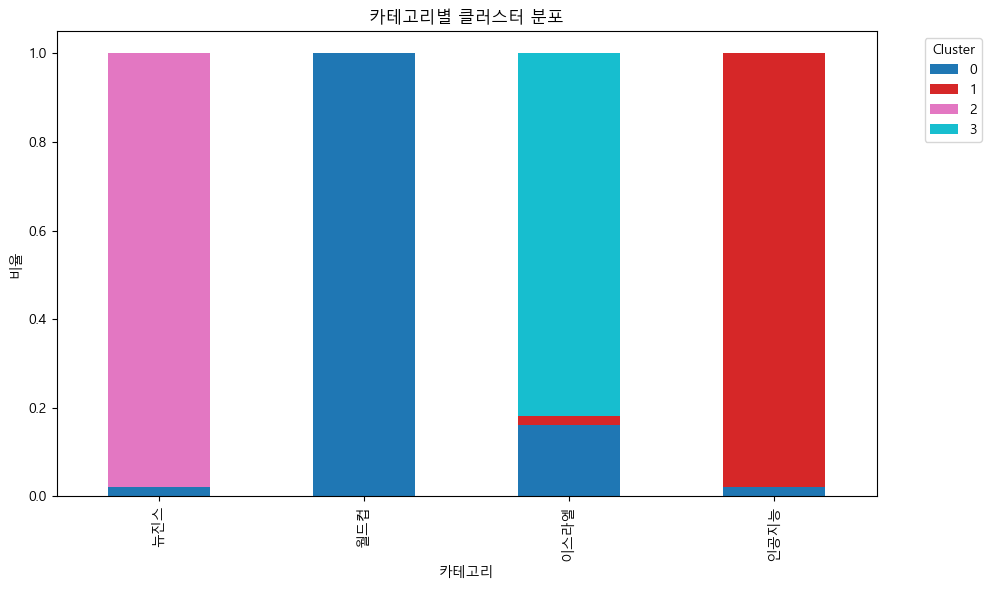

In [7]:
# 클러스터 레이블을 video_df에 추가
video_df['cluster'] = kmeans.labels_

# 교차표 생성
cross = pd.crosstab(video_df['category'], video_df['cluster'], margins=True)
print('=== 카테고리 × 클러스터 교차표 ===')
print(cross)

# 비율 교차표 (행 기준)
cross_pct = pd.crosstab(video_df['category'], video_df['cluster'], normalize='index')
print('\n=== 카테고리별 클러스터 비율 ===')
print(cross_pct.round(3))

# 시각화: 스택 바 차트
cross_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')
plt.title('카테고리별 클러스터 분포')
plt.xlabel('카테고리')
plt.ylabel('비율')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('category_cluster_distribution.png', dpi=150)
plt.show()